Colab of strabismus analysis using neural networks

In [2]:
import pandas as pd
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import os
import random
import tensorflow as tf
from tensorflow.keras import callbacks, optimizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D
from tensorflow.keras.models import Model



2025-03-03 10:17:17.018777: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-03 10:17:17.106893: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-03 10:17:17.110019: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/pedro/anaconda3/envs/strabismus/lib/python3.7/site-packages/cv2/../../lib64:


In [15]:
BASE_PATH = '../Dataset'
list_of_cases = os.listdir(BASE_PATH)
list_of_cases

['ESOTROPIA', 'HYPERTROPIA', 'NORMAL', 'HYPOTROPIA', 'EXOTROPIA']

In [13]:
classes = ['esotropia',
 'exotropia',
 'hypertropia',
 'hypotropia',
 'normal']

In [21]:
classes = [x.upper() for x in classes]
classes

['ESOTROPIA', 'EXOTROPIA', 'HYPERTROPIA', 'HYPOTROPIA', 'NORMAL']

In [22]:
# verify the GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
  try:
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    print(f'Using GPUs: {gpus}')
  except RuntimeError as e:
    print(e)
else:
  print('No GPUs found')

No GPUs found


In [23]:
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [24]:
label_map = {y:x for x,y in enumerate(classes)}
label_map

{'ESOTROPIA': 0,
 'EXOTROPIA': 1,
 'HYPERTROPIA': 2,
 'HYPOTROPIA': 3,
 'NORMAL': 4}

In [25]:
# Using a low pass filter
def low_pass_filter(img, kernel_size):
  return cv.blur(img, (kernel_size, kernel_size))

In [26]:
for case in list_of_cases:
    print(f'Processing case: {case}')

Processing case: ESOTROPIA
Processing case: HYPERTROPIA
Processing case: NORMAL
Processing case: HYPOTROPIA
Processing case: EXOTROPIA


In [97]:
images = []
labels = []
filenames = []
count = 0
treated_data = {}

for folder in list_of_cases:
  if folder in classes:
    count2 = 0
    list_of_files = os.listdir(os.path.join(BASE_PATH, folder))
    print(f'Processing case: {folder}')

    for file_ in list_of_files:
      #print(f'file_: {file_}')
      if 'exc' not in file_:
        img = cv.imread(os.path.join(BASE_PATH, folder, file_))
        if img is not None:
          img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
          img2 = cv.resize(img, (224, 96), interpolation=cv.INTER_AREA)
          #img2 = low_pass_filter(img2, 3)
          img2 = img2.astype('float32') / 255.0
          images.append(img2)
          labels.append(label_map[folder])
          filenames.append(file_)
          count += 1
          count2+= 1
    treated_data[folder] = count2
print(f"Number of images processed: {count}")

Processing case: ESOTROPIA
Processing case: HYPERTROPIA
Processing case: NORMAL
Processing case: HYPOTROPIA
Processing case: EXOTROPIA
Number of images processed: 479


In [99]:
treated_data = pd.DataFrame(treated_data.items(), columns=['Case', 'Count'])

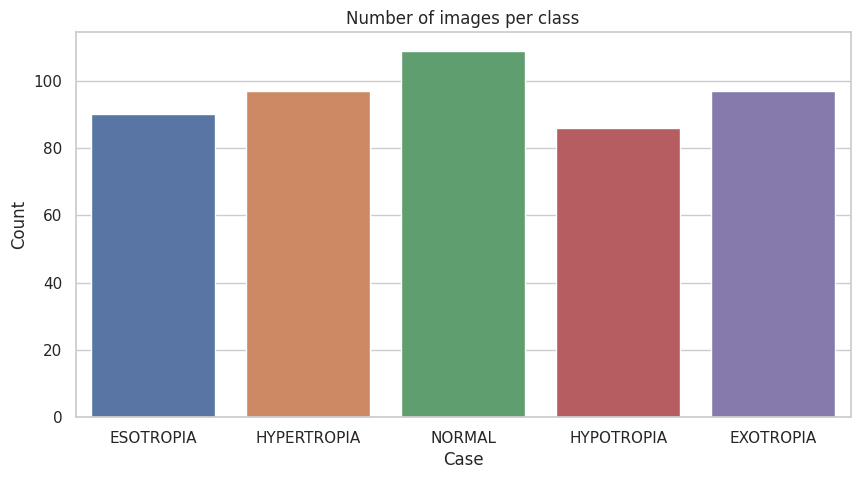

In [109]:
# Print the number of images per class
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
sns.barplot(x='Case', y='Count', data=treated_data)
plt.title('Number of images per class')
plt.show()

In [49]:
# Convertendo as listas para numpy
images = np.array(images)
labels = np.array(labels)

In [50]:
print(images.shape)
print(labels.shape)

(479, 96, 224, 3)
(479,)


In [51]:
# Realizando o one hot encoding
num_of_classes = len(classes)
labels = tf.keras.utils.to_categorical(labels, num_of_classes)

In [52]:
# Shuffle dataset
indices = np.arange(len(images))
np.random.shuffle(indices)
images = images[indices]
labels = labels[indices]


In [53]:
# Separando as imagens
train_images = images[:int(0.8*len(images))]
train_labels = labels[:int(0.8*len(labels))]
test_images = images[int(0.8*len(images)):]
test_labels = labels[int(0.8*len(labels)):]

In [54]:
print(train_images.shape)
print(train_labels.shape)
print(test_images.shape)
print(test_labels.shape)

(383, 96, 224, 3)
(383, 5)
(96, 96, 224, 3)
(96, 5)


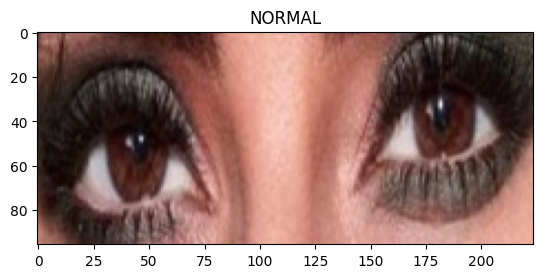

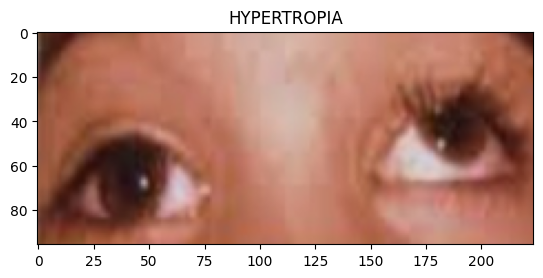

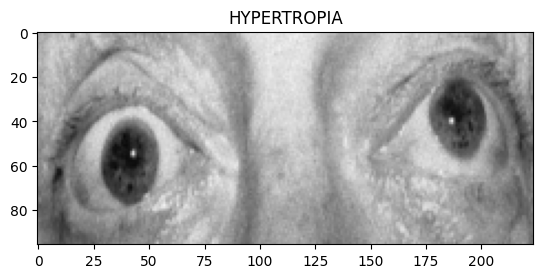

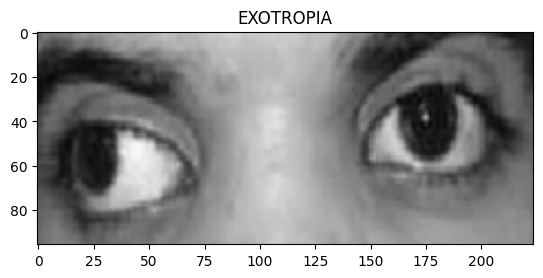

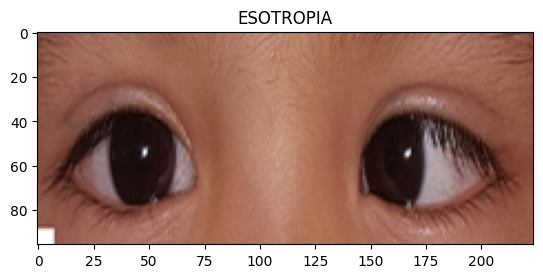

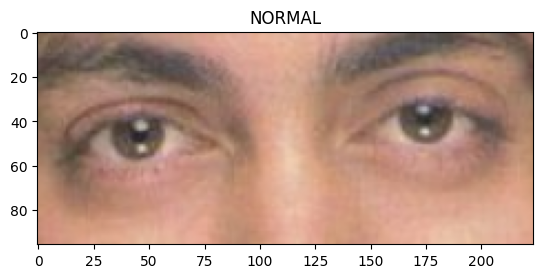

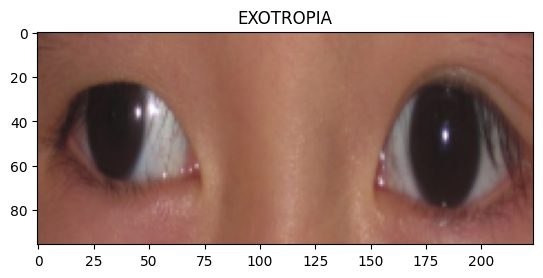

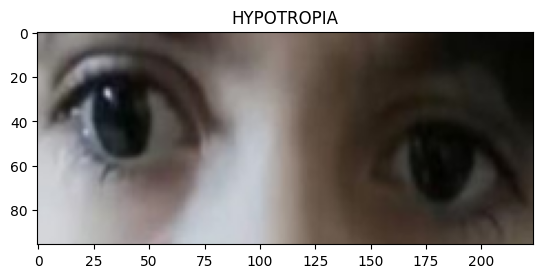

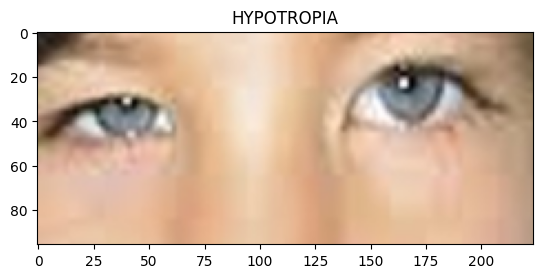

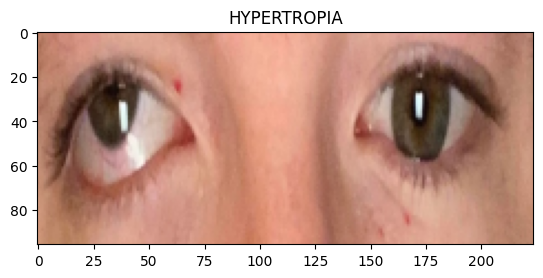

In [55]:
# print some images
for i in range(10):
    plt.imshow(train_images[i])
    plt.title(classes[np.argmax(train_labels[i])])
    plt.show()

In [65]:
# Carregando o Modelo baseado na Resnet50
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(96, 224, 3))
base_model.trainable = False

In [66]:
# Customizando o modelo
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)

predictions = Dense(num_of_classes, activation='softmax')(x)

In [67]:
# Juntando o modelo completo
model = Model(inputs=base_model.input, outputs=predictions)

In [68]:
model.compile(optimizer=optimizers.Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 96, 224, 3)  0           []                               
                                ]                                                                 
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 102, 230, 3)  0           ['input_3[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 48, 112, 64)  9472        ['conv1_pad[0][0]']              
                                                                                                  
 conv1_bn (BatchNormalization)  (None, 48, 112, 64)  256         ['conv1_conv[0][0]']       

In [78]:
tensorboard_callback = callbacks.TensorBoard(log_dir='../logs')

In [79]:
class TestEvaluationCallback(callbacks.Callback):
    def __init__(self, test_data, filepath):
        super(TestEvaluationCallback, self).__init__()
        self.test_data = test_data
        self.test_losses = []
        self.test_accuracies = []
        self.best_accuracy  = 0.0
        self.filepath = filepath

    def on_epoch_end(self, epoch, logs=None):
        x, y = self.test_data
        loss, accuracy = self.model.evaluate(x, y, verbose=0)
        self.test_losses.append(loss)
        self.test_accuracies.append(accuracy)
        print(f"\nEpoch: {epoch + 1} Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

        if accuracy > self.best_accuracy:
            self.best_accuracy = accuracy
            self.model.save(self.filepath + "/model" + "_" + str(epoch + 1) + ".h5")
            print(f"Model saved on {self.filepath}/model_{epoch + 1}.h5")

In [80]:
model_path = '../Models'
if not os.path.exists(model_path):
    os.makedirs(model_path)
test_eval_callback = TestEvaluationCallback((test_images, test_labels), model_path)

In [81]:
# Train the Model
epochs = 1000
batch_size = 16
history = model.fit(train_images, train_labels, epochs=epochs, batch_size=batch_size, validation_split=0.2, callbacks=[tensorboard_callback, test_eval_callback])

Epoch 1/1000
20/20 [==============================] - ETA: 0s - loss: 1.0396 - accuracy: 0.6013
Epoch: 1 Test Loss: 1.1967, Test Accuracy: 0.5104
Model saved on ../Models/model_1.h5
20/20 [==============================] - 7s 367ms/step - loss: 1.0396 - accuracy: 0.6013 - val_loss: 1.4395 - val_accuracy: 0.4935
Epoch 2/1000
20/20 [==============================] - ETA: 0s - loss: 1.0513 - accuracy: 0.5915
Epoch: 2 Test Loss: 1.1659, Test Accuracy: 0.5208
Model saved on ../Models/model_2.h5
20/20 [==============================] - 7s 366ms/step - loss: 1.0513 - accuracy: 0.5915 - val_loss: 1.3781 - val_accuracy: 0.4935
Epoch 3/1000
20/20 [==============================] - ETA: 0s - loss: 1.0223 - accuracy: 0.6046
Epoch: 3 Test Loss: 1.1477, Test Accuracy: 0.5104
20/20 [==============================] - 7s 352ms/step - loss: 1.0223 - accuracy: 0.6046 - val_loss: 1.3581 - val_accuracy: 0.5195
Epoch 4/1000
20/20 [==============================] - ETA: 0s - loss: 1.0273 - accuracy: 0.6144
E

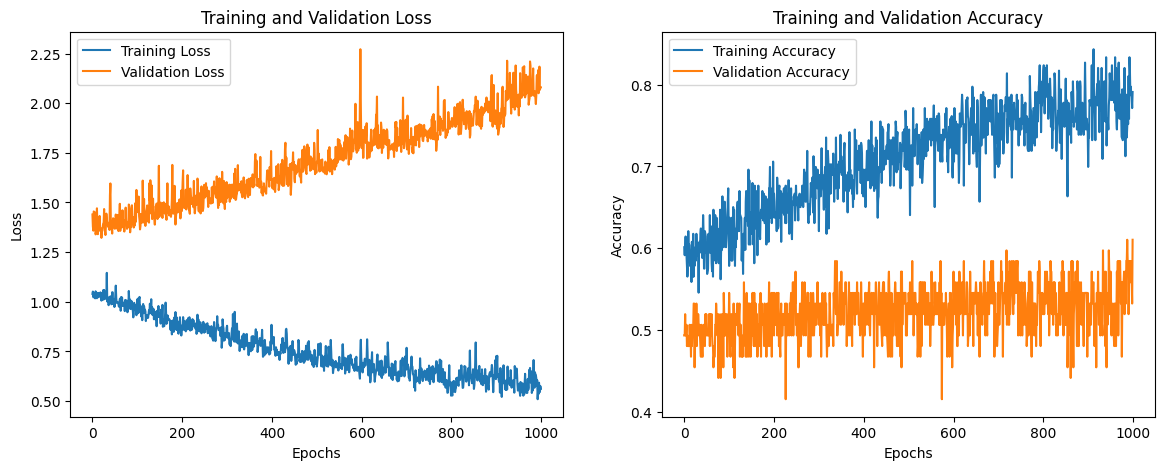

In [82]:
# Imprimindo o histórico de treinamento
# Loss
plt.figure(figsize = (14,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

In [92]:
# Model Evaluator
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, roc_curve, auc

class model_evaluator():
    def __init__(self, model_path, test_images, test_labels, classes):
        self.model_path = model_path
        self.test_images = test_images
        self.test_labels = test_labels
        self.model = tf.keras.models.load_model(self.model_path)
        self.class_names = classes

    def evaluate_model(self):
        predictions = self.model.predict(self.test_images)
        y_pred = np.argmax(predictions, axis=1)
        y_true = np.argmax(self.test_labels, axis=1)

        # Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)
        print(cm)

        # Classification Report
        cr = classification_report(y_true, y_pred, target_names=self.class_names)
        print(cr)

        # Calculate Specificity and Sensitivity
        sensitivity = {}
        specificity = {}

        for i in range(len(self.class_names)):
            TP = cm[i, i]
            FN = np.sum(cm[i, :]) - TP
            FP = np.sum(cm[:, i]) - TP
            TN = np.sum(cm) - TP - FN - FP

            sensitivity[self.class_names[i]] = TP / (TP + FN)
            specificity[self.class_names[i]] = TN / (TN + FP)

        # Print Sensitivity and Specificity for every class
        for key, value in sensitivity.items():
            print(f'{key} Sensitivity: {value}')
            print(f'{key} Specificity: {specificity[key]}')

    # Plotting the ROC Curve
    def plot_roc_curve(self):
        plt.figure(figsize=(10, 10))
        for i in range(len(self.class_names)):
            fpr, tpr, _ = roc_curve(self.test_labels[:, i], self.model.predict(self.test_images)[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'{self.class_names[i]} (AUC = {roc_auc:.2f})')
        
        plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal line for random classifier
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curves')
        plt.legend(loc="lower right")
        plt.show()


    
    

In [93]:
evaluator = model_evaluator(model_path + '/model_803.h5', test_images, test_labels, classes)
evaluator.evaluate_model()


3/3 [==============================] - 2s 445ms/step
[[12  0  1  2  1]
 [ 2 14  2  3  2]
 [ 0  8 10  1  1]
 [ 0  1  5  8  1]
 [ 1  2  1  2 16]]
              precision    recall  f1-score   support

   ESOTROPIA       0.80      0.75      0.77        16
   EXOTROPIA       0.56      0.61      0.58        23
 HYPERTROPIA       0.53      0.50      0.51        20
  HYPOTROPIA       0.50      0.53      0.52        15
      NORMAL       0.76      0.73      0.74        22

    accuracy                           0.62        96
   macro avg       0.63      0.62      0.63        96
weighted avg       0.63      0.62      0.63        96

ESOTROPIA Sensitivity: 0.75
ESOTROPIA Specificity: 0.9625
EXOTROPIA Sensitivity: 0.6086956521739131
EXOTROPIA Specificity: 0.8493150684931506
HYPERTROPIA Sensitivity: 0.5
HYPERTROPIA Specificity: 0.881578947368421
HYPOTROPIA Sensitivity: 0.5333333333333333
HYPOTROPIA Specificity: 0.9012345679012346
NORMAL Sensitivity: 0.7272727272727273
NORMAL Specificity: 0.932432

3/3 [==============================] - 1s 443ms/step


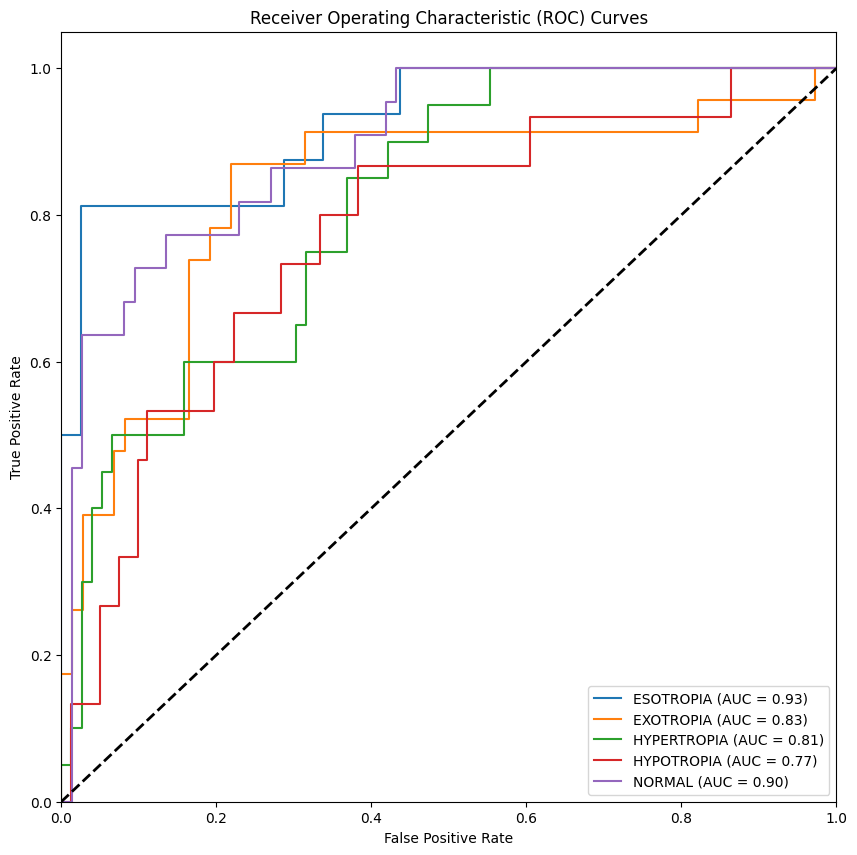

In [94]:
evaluator.plot_roc_curve()